In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pymcel as pc
from astropy.coordinates import SkyCoord
from astropy import units as u

In [55]:
df = pd.read_csv('observaciones_astrometricas.csv')

In [56]:
print(df.head())

  object_key   object_name   object_type horizons_id             datetime_utc  \
0   oumuamua  1I/'Oumuamua  interestelar          1I  2017-10-19 23:58:50.818   
1   oumuamua  1I/'Oumuamua  interestelar          1I  2017-10-20 23:58:50.818   
2   oumuamua  1I/'Oumuamua  interestelar          1I  2017-10-21 23:58:50.818   
3   oumuamua  1I/'Oumuamua  interestelar          1I  2017-10-22 23:58:50.818   
4   oumuamua  1I/'Oumuamua  interestelar          1I  2017-10-23 23:58:50.818   

                     datetime_tdb   t_jd_tdb     ra_deg   dec_deg    rho_au  \
0  A.D. 2017-Oct-20 00:00:00.0000  2458046.5  20.270964  3.103206  0.245243   
1  A.D. 2017-Oct-21 00:00:00.0000  2458047.5  15.433589  3.571600  0.272808   
2  A.D. 2017-Oct-22 00:00:00.0000  2458048.5  11.509500  3.936825  0.302073   
3  A.D. 2017-Oct-23 00:00:00.0000  2458049.5   8.296589  4.226159  0.332618   
4  A.D. 2017-Oct-24 00:00:00.0000  2458050.5   5.638788  4.459586  0.364148   

   sigma_ra_arcsec  sigma_dec_arcsec  

In [57]:
# Solo datos de Apophis
df_apophis = df[df["object_key"] == "apophis"].copy()

print(df_apophis)

    object_key    object_name object_type horizons_id  \
72     apophis  99942 Apophis         NEO       99942   
73     apophis  99942 Apophis         NEO       99942   
74     apophis  99942 Apophis         NEO       99942   
75     apophis  99942 Apophis         NEO       99942   
76     apophis  99942 Apophis         NEO       99942   
77     apophis  99942 Apophis         NEO       99942   
78     apophis  99942 Apophis         NEO       99942   
79     apophis  99942 Apophis         NEO       99942   
80     apophis  99942 Apophis         NEO       99942   
81     apophis  99942 Apophis         NEO       99942   
82     apophis  99942 Apophis         NEO       99942   
83     apophis  99942 Apophis         NEO       99942   
84     apophis  99942 Apophis         NEO       99942   
85     apophis  99942 Apophis         NEO       99942   
86     apophis  99942 Apophis         NEO       99942   
87     apophis  99942 Apophis         NEO       99942   
88     apophis  99942 Apophis  

In [58]:
#reiniciar el índice del DataFrame
df_apophis.reset_index(drop=True, inplace=True)
print(df_apophis)

   object_key    object_name object_type horizons_id             datetime_utc  \
0     apophis  99942 Apophis         NEO       99942  2021-02-28 23:58:50.815   
1     apophis  99942 Apophis         NEO       99942  2021-03-01 11:58:50.815   
2     apophis  99942 Apophis         NEO       99942  2021-03-01 23:58:50.815   
3     apophis  99942 Apophis         NEO       99942  2021-03-02 11:58:50.815   
4     apophis  99942 Apophis         NEO       99942  2021-03-02 23:58:50.815   
5     apophis  99942 Apophis         NEO       99942  2021-03-03 11:58:50.815   
6     apophis  99942 Apophis         NEO       99942  2021-03-03 23:58:50.815   
7     apophis  99942 Apophis         NEO       99942  2021-03-04 11:58:50.815   
8     apophis  99942 Apophis         NEO       99942  2021-03-04 23:58:50.815   
9     apophis  99942 Apophis         NEO       99942  2021-03-05 11:58:50.815   
10    apophis  99942 Apophis         NEO       99942  2021-03-05 23:58:50.815   
11    apophis  99942 Apophis

In [59]:
tiempo = df_apophis['t_jd_tdb']
RA = df_apophis['ra_deg']
Dec = df_apophis['dec_deg']
Rho = df_apophis['rho_au']
Earth_x = df_apophis['earth_x_au']
Earth_y = df_apophis['earth_y_au']
Earth_z = df_apophis['earth_z_au']

In [60]:
#llevar el cambio de coordenadas a un sistema cartesiano
coords = SkyCoord(ra=RA.values*u.deg, dec=Dec.values*u.deg, distance=Rho.values*u.au)
apophis_x = coords.cartesian.x
apophis_y = coords.cartesian.y
apophis_z = coords.cartesian.z

In [61]:
from astropy.coordinates import CartesianRepresentation, BarycentricMeanEcliptic

# Crear una representación cartesiana
cart = CartesianRepresentation(apophis_x, apophis_y, apophis_z)

# Convertir a coordenadas eclípticas (baricéntricas)
ecliptic_coords = BarycentricMeanEcliptic(cart)

# Extraer longitud, latitud y distancia eclípticas
lambda_ecl = ecliptic_coords.lon
beta_ecl = ecliptic_coords.lat
r_ecl = ecliptic_coords.distance

print(f"Longitud eclíptica: {lambda_ecl}")
print(f"Latitud eclíptica: {beta_ecl}")
print(f"Distancia: {r_ecl}")# Crear objeto con coordenadas eclípticas

Longitud eclíptica: [147.41541593 146.83442212 146.254863   145.6771331  145.101625
 144.52872864 143.95883059 143.39231306 142.8295529  142.27092049
 141.71677857 141.16748104 140.62337178 140.08478353 139.55203671
 139.02543849 138.50528175 137.99184427 137.48538799 136.98615832
 136.49438365 136.01027491 135.53402528 135.06581001 134.60578635
 134.1540936  133.71085327 133.27616938 132.85012877 132.43280154
 132.02424161 131.62448724 131.23356169 130.85147382 130.4782188
 130.1137788  129.75812362 129.41121141 129.07298934] deg
Latitud eclíptica: [-11.38268962 -11.03146543 -10.67459337 -10.31234074  -9.94498507
  -9.57281363  -9.19612273  -8.81521705  -8.43040873  -8.04201642
  -7.65036427  -7.25578072  -6.85859731  -6.45914743  -6.05776499
  -5.6547831   -5.25053277  -4.84534161  -4.43953257  -4.03342273
  -3.62732219  -3.22153292  -2.81634787  -2.41204998  -2.00891146
  -1.60719303  -1.20714341  -0.80899874  -0.4129823   -0.01930419
   0.37183879   0.76026328   1.14579925   1.5282

In [62]:
ecliptic_frame = BarycentricMeanEcliptic(lon=lambda_ecl, lat=beta_ecl, distance=r_ecl)

# Convertir a representación cartesiana
cart_recovered = ecliptic_frame.cartesian

# Extraer componentes
apophis_x_new = cart_recovered.x
apophis_y_new = cart_recovered.y
apophis_z_new = cart_recovered.z

print(f"X: {apophis_x_new}")
print(f"Y: {apophis_y_new}")
print(f"Z: {apophis_z_new}")

X: [-0.09416691 -0.09345602 -0.09275795 -0.09207273 -0.0914004  -0.090741
 -0.09009458 -0.08946119 -0.08884086 -0.08823365 -0.0876396  -0.08705875
 -0.08649113 -0.08593678 -0.08539571 -0.08486795 -0.08435352 -0.08385241
 -0.08336462 -0.08289014 -0.08242895 -0.08198101 -0.0815463  -0.08112475
 -0.08071632 -0.08032094 -0.07993852 -0.07956899 -0.07921225 -0.0788682
 -0.07853673 -0.07821772 -0.07791105 -0.07761657 -0.07733416 -0.07706366
 -0.07680492 -0.07655779 -0.07632209] AU
Y: [0.06018656 0.06107575 0.06196749 0.06286162 0.06375795 0.0646563
 0.0655565  0.06645836 0.06736169 0.06826628 0.06917193 0.07007842
 0.07098555 0.07189308 0.0728008  0.07370846 0.07461583 0.07552266
 0.07642872 0.07733375 0.07823751 0.07913974 0.08004019 0.08093861
 0.08183474 0.08272835 0.08361917 0.08450696 0.08539147 0.08627246
 0.0871497  0.08802294 0.08889196 0.08975652 0.0906164  0.09147138
 0.09232126 0.0931658  0.09400482] AU
Z: [-2.24992111e-02 -2.17649372e-02 -2.10268761e-02 -2.02851174e-02
 -1.9539751

In [63]:
print(apophis_x[-1])

-0.07632209128260867 AU


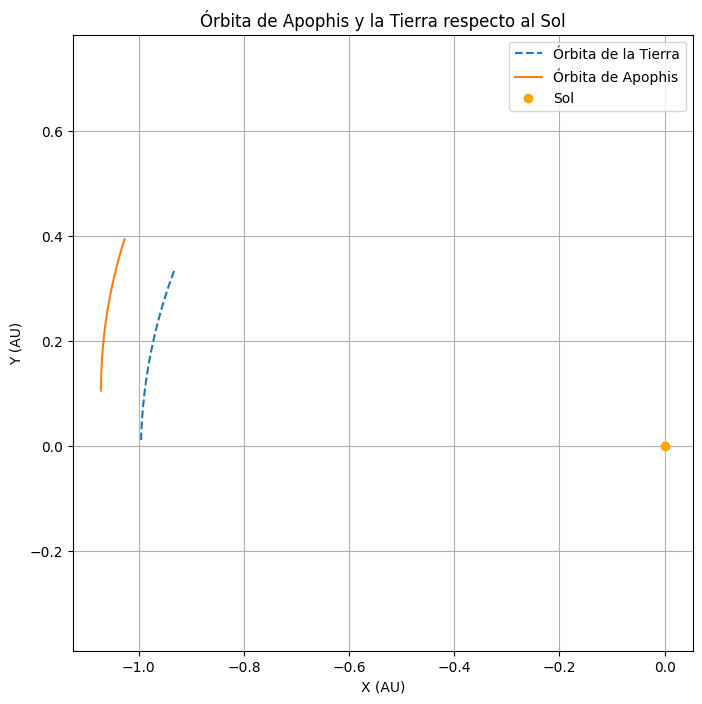

In [64]:
# Asignar unidades a las coordenadas de la Tierra
earth_x_au = Earth_x.values * u.au
earth_y_au = Earth_y.values * u.au
earth_z_au = Earth_z.values * u.au

# Sumar las coordenadas de la Tierra (respecto al Sol) con las de Apophis (respecto a la Tierra)
# para obtener las coordenadas de Apophis respecto al Sol.
apophis_sun_x = earth_x_au + apophis_x_new
apophis_sun_y = earth_y_au + apophis_y_new
apophis_sun_z = earth_z_au + apophis_z_new

# Graficar la órbita de la Tierra y la de Apophis respecto al Sol
plt.figure(figsize=(8, 8))
plt.plot(earth_x_au, earth_y_au, label='Órbita de la Tierra', linestyle='--')
plt.plot(apophis_sun_x, apophis_sun_y, label='Órbita de Apophis')
plt.plot(0, 0, 'o', color='orange', label='Sol') # Marcar el Sol en el origen
plt.xlabel('X (AU)')
plt.ylabel('Y (AU)')
plt.title('Órbita de Apophis y la Tierra respecto al Sol')
plt.legend()
plt.grid(True)
plt.axis('equal') # Asegura que la escala en X e Y sea la misma
plt.show()

In [77]:
# escoge un elemento de la posicion aleatoria para calcular la velocidad en un delta t 
N = len(tiempo)
random_index = np.random.randint(1, N) # Empezar desde 1 para evitar índice -1
print(f"Índice aleatorio: {random_index}")
print(f"Tiempo seleccionado: {tiempo[random_index]}")

# Calcular componentes de velocidad y quitar unidades
vx = (apophis_x_new[random_index] - apophis_x_new[random_index-1]) / (tiempo[random_index] - tiempo[random_index-1])
vy = (apophis_y_new[random_index] - apophis_y_new[random_index-1]) / (tiempo[random_index] - tiempo[random_index-1])
vz = (apophis_z_new[random_index] - apophis_z_new[random_index-1]) / (tiempo[random_index] - tiempo[random_index-1])

# Crear el vector de velocidad como un array de NumPy sin unidades
v_vec = np.array([vx.value, vy.value, vz.value])

print(f"Velocidad: {v_vec} AU/d")

Índice aleatorio: 27
Tiempo seleccionado: 2459288.0
Velocidad: [0.00073906 0.00177558 0.00159723] AU/d


In [78]:
v

(<Quantity 0.00131879 AU>, <Quantity 0.00179671 AU>, <Quantity 0.00149777 AU>)

In [79]:
# Extraer los valores numéricos del vector de posición (sin unidades)
r_vec = np.array([
    apophis_x_new[random_index].value,
    apophis_y_new[random_index].value,
    apophis_z_new[random_index].value
])

r = np.linalg.norm(r_vec)

# Calcular el momento angular específico (ahora ambos vectores no tienen unidades)
h_vec = np.cross(r_vec, v_vec)
h = np.linalg.norm(h_vec)

print(f"Momento angular específico: {h_vec} AU^2/d")
print(f"Magnitud del momento angular específico: {h} AU^2/d")

Momento angular específico: [ 0.00013789  0.00012588 -0.00020374] AU^2/d
Magnitud del momento angular específico: 0.0002763458822014351 AU^2/d


In [80]:
mu = pc.constantes.mu_sun
p = h**2 / mu

e = np.cross(v_vec, h_vec) / mu - r_vec / r

tetaers = np.linspace(0, 360, N) * u.deg
r_orbita = p / (1 + e * np.cos(tetaers)) # Usamos la excentricidad e = 0.19 para Apophis

ValueError: operands could not be broadcast together with shapes (39,) (3,) 